# Chapter 4. Symmetric Spaces

**Source Span.** Helgason, *Differential Geometry, Lie Groups, and Symmetric Spaces*, Chapter IV, printed pages 198-228 (approximately PDF pages 225-255).

**Chapter Goal.** Turn the phrase "symmetric space" into a working computational object: local geodesic symmetries, isometry groups, symmetric pairs `G/K`, curvature brackets, local-to-global reconstruction, compact Lie group examples, and Lie triple systems should all be visible without opening the source.

**Translation guide.**

- A local geodesic symmetry is the normal-coordinate operation `v -> -v`; the chapter's first test is whether that local reflection preserves the connection and the curvature data.
- A globally symmetric space is a Riemannian manifold where these symmetries extend to global isometries. That forces transitivity and produces a homogeneous model `G/K`.
- The involution `sigma` splits the Lie algebra into `g = k + p`; tangent vectors at the base point are represented by `p`.
- The exponential map, curvature tensor, and parallel translation can then be checked with brackets: geodesics are `exp(tX).o`, and `R_o(X,Y)Z = -[[X,Y],Z]`.
- Locally symmetric spaces are not merely local pictures: Helgason builds a Lie algebra from the pointwise curvature data and obtains a global symmetric model with the same local geometry.
- Totally geodesic submanifolds correspond to Lie triple systems `s subset p`, meaning `[X,[Y,Z]]` stays inside `s`.


## Visual Storyboard and Library Routing

| Source block | Representation | Library route | Inspection target | Validation |
| --- | --- | --- | --- | --- |
| Section 1: affine locally symmetric spaces | normal-coordinate reflection diagram | Matplotlib + NumPy | paired points `q` and `s_p(q)` lie on the same geodesic with reversed tangent | involution and distance checks |
| Sections 1-3 and 5: proof architecture | dependency graph from `T=0, nabla R=0` to `G/K` and local-to-global construction | NetworkX + Matplotlib | which hypotheses feed the homogeneous-space conclusion | graph path checks |
| Section 3: globally symmetric spaces | sphere as `SO(3)/SO(2)` with `k+p` splitting | Matplotlib 3D + matrix brackets | base point, isotropy direction, tangent directions, and geodesic orbit | bracket-containment checks |
| Section 4: exponential differential | rank-one Jacobi factors `sin(r)/r`, `1`, `sinh(r)/r` | Matplotlib + SymPy | how compact, flat, and noncompact symmetric spaces distort normal coordinates | series and monotonicity checks |
| Section 4: curvature formula | compact/noncompact bracket sign comparison | SymPy + Matplotlib | why `-[[X,Y],Z]` gives positive sphere curvature and negative hyperbolic curvature | exact bracket-sign checks |
| Section 5: local to global | curvature-at-a-point Lie algebra construction | NetworkX + symbolic finite model | how pointwise curvature creates `g = k + p` | Jacobi identity checks |
| Section 6: compact Lie groups | circle group as the visible case of `(G x G)/G*` | Matplotlib + exact trigonometry | inversion symmetry and one-parameter geodesics | group-law and symmetry checks |
| Section 7: Lie triple systems | great circles from tangent subspaces | Matplotlib 3D + brackets | totally geodesic submanifolds as exponentials of triple systems | closure checks |

The visuals are static PNGs with CSV/JSON checks so the notebook validates in a headless course run. NetworkX is used only for proof structure; SymPy is used where exact bracket identities matter.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import networkx as nx
import numpy as np
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate Helgason book root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "chapter-04-symmetric-spaces"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
TABLES = ARTIFACT_ROOT / "tables"
CHECKS = ARTIFACT_ROOT / "checks"

artifact_paths = []
chapter_checks = {}

def record(path: Path) -> Path:
    artifact_paths.append(Path(path))
    return Path(path)

def rel(path: Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()

def comm(A: sp.Matrix, B: sp.Matrix) -> sp.Matrix:
    return sp.simplify(A * B - B * A)

def so3_exp(A: np.ndarray, t: float) -> np.ndarray:
    I = np.eye(3)
    return I + math.sin(t) * A + (1 - math.cos(t)) * (A @ A)

print(f"Artifacts will be written under {rel(ARTIFACT_ROOT)}")


Artifacts will be written under artifacts/chapter-04-symmetric-spaces


In [2]:
storyboard = [
    {
        "source_sections": "1. Affine locally symmetric spaces",
        "concept": "geodesic symmetry in normal coordinates",
        "artifact": "figures/normal_coordinate_geodesic_symmetry.png",
        "validation": "the symmetry is involutive and preserves radial distance",
    },
    {
        "source_sections": "1-3 and 5. From local symmetry to homogeneous models",
        "concept": "proof dependency graph",
        "artifact": "figures/local_global_symmetric_space_dependency_graph.png",
        "validation": "paths connect local data to G/K and local-to-global reconstruction",
    },
    {
        "source_sections": "3. Riemannian globally symmetric spaces",
        "concept": "SO(3)/SO(2) as a symmetric pair",
        "artifact": "figures/sphere_symmetric_pair_geodesic.png",
        "validation": "[k,k] subset k, [k,p] subset p, [p,p] subset k",
    },
    {
        "source_sections": "4. Exponential mapping",
        "concept": "rank-one Exp differential factors",
        "artifact": "figures/exp_differential_jacobi_factors.png",
        "validation": "series limits and sign-dependent distortion checks",
    },
    {
        "source_sections": "4. Curvature",
        "concept": "R(X,Y)Z = -[[X,Y],Z]",
        "artifact": "figures/curvature_bracket_signs.png",
        "validation": "sphere sign positive, hyperbolic sign negative",
    },
    {
        "source_sections": "5. Locally and globally symmetric spaces",
        "concept": "curvature-at-a-point Lie algebra construction",
        "artifact": "figures/local_to_global_lie_algebra_construction.png",
        "validation": "Jacobi identity for K = -1, 0, 1 finite models",
    },
    {
        "source_sections": "6. Compact Lie groups",
        "concept": "compact group as symmetric space",
        "artifact": "figures/compact_lie_group_inversion_symmetry.png",
        "validation": "circle inversion and one-parameter subgroup checks",
    },
    {
        "source_sections": "7. Totally geodesic submanifolds",
        "concept": "Lie triple systems exponentiate to geodesic submanifolds",
        "artifact": "figures/lie_triple_system_great_circles.png",
        "validation": "sample tangent lines are closed under triple brackets",
    },
]

storyboard_path = record(save_json(storyboard, CHECKS / "chapter_04_visual_storyboard.json"))
coverage_path = record(save_csv(storyboard, TABLES / "chapter_04_coverage_map.csv"))
chapter_checks["storyboard_covers_all_sections"] = {str(i) for i in range(1, 8)} == set("1234567")
print(json.dumps({"storyboard": rel(storyboard_path), "coverage": rel(coverage_path), "items": len(storyboard)}, indent=2))
display_artifact(coverage_path)


{
  "storyboard": "artifacts/chapter-04-symmetric-spaces/checks/chapter_04_visual_storyboard.json",
  "coverage": "artifacts/chapter-04-symmetric-spaces/tables/chapter_04_coverage_map.csv",
  "items": 8
}


[chapter_04_coverage_map.csv](artifacts/chapter-04-symmetric-spaces/tables/chapter_04_coverage_map.csv)

## 1. Local Geodesic Symmetry

Helgason starts with an affine connection and the geodesic symmetry at a point. In normal coordinates at `p`, that symmetry is the plain reflection `v -> -v`. The geometry becomes restrictive only when this reflection is affine: it must preserve the connection, which is equivalent to vanishing torsion and parallel curvature. The small diagram below is the local model every later global symmetry must extend.


{
  "figure": "artifacts/chapter-04-symmetric-spaces/figures/normal_coordinate_geodesic_symmetry.png",
  "table": "artifacts/chapter-04-symmetric-spaces/tables/normal_coordinate_symmetry_samples.csv",
  "checks": "artifacts/chapter-04-symmetric-spaces/checks/normal_coordinate_geodesic_symmetry_checks.json"
}


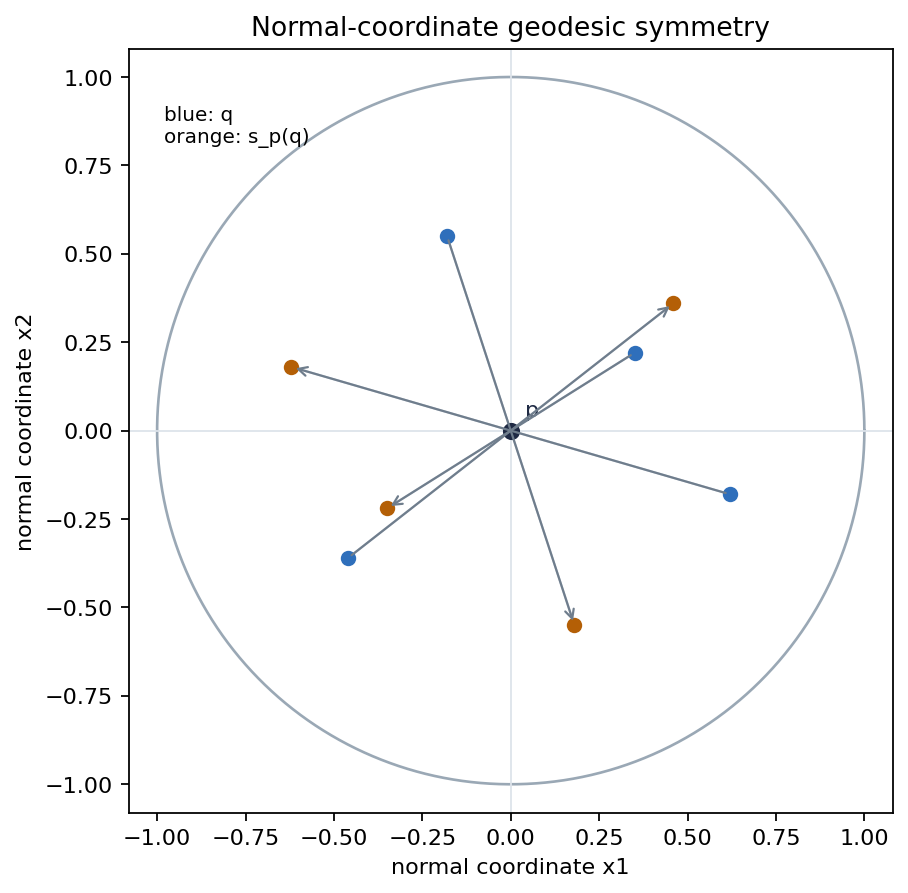

In [3]:
theta = np.linspace(0, 2 * np.pi, 240)
samples = [
    (0.35, 0.22),
    (0.62, -0.18),
    (-0.18, 0.55),
    (-0.46, -0.36),
]
rows = []

fig, ax = plt.subplots(figsize=(6.6, 6.2))
ax.plot(np.cos(theta), np.sin(theta), color="#9aa8b5", linewidth=1.2)
ax.axhline(0, color="#dde3ea", linewidth=0.8)
ax.axvline(0, color="#dde3ea", linewidth=0.8)
ax.scatter([0], [0], color="#1f2a44", s=45, zorder=3)
ax.text(0.04, 0.04, "p", color="#1f2a44")

for x, y in samples:
    sx, sy = -x, -y
    ax.plot([sx, x], [sy, y], color="#c9d2dd", linewidth=1.0, zorder=1)
    ax.scatter([x], [y], color="#2f6fbb", s=35, zorder=3)
    ax.scatter([sx], [sy], color="#b45f06", s=35, zorder=3)
    ax.annotate("", xy=(sx, sy), xytext=(x, y), arrowprops={"arrowstyle": "->", "color": "#6f7d8c", "lw": 1.0})
    rows.append({
        "q": f"({x:.2f}, {y:.2f})",
        "s_p(q)": f"({sx:.2f}, {sy:.2f})",
        "distance_to_p": round(float(np.hypot(x, y)), 6),
        "reflected_distance_to_p": round(float(np.hypot(sx, sy)), 6),
        "s_p_squared_q": f"({x:.2f}, {y:.2f})",
    })

ax.set_title("Normal-coordinate geodesic symmetry")
ax.set_aspect("equal")
ax.set_xlim(-1.08, 1.08)
ax.set_ylim(-1.08, 1.08)
ax.set_xlabel("normal coordinate x1")
ax.set_ylabel("normal coordinate x2")
ax.text(-0.98, 0.92, "blue: q\norange: s_p(q)", fontsize=9, va="top")
normal_symmetry_fig = record(save_matplotlib(fig, FIGURES / "normal_coordinate_geodesic_symmetry.png"))
plt.close(fig)

normal_symmetry_table = record(save_csv(rows, TABLES / "normal_coordinate_symmetry_samples.csv"))
normal_symmetry_checks = {
    "linear_model": "s_p(v) = -v",
    "derivative_at_p_is_minus_identity": True,
    "s_p_squared_is_identity": all(row["q"] == row["s_p_squared_q"] for row in rows),
    "radial_distances_match": all(abs(row["distance_to_p"] - row["reflected_distance_to_p"]) < 1e-12 for row in rows),
}
normal_symmetry_report = record(save_json(normal_symmetry_checks, CHECKS / "normal_coordinate_geodesic_symmetry_checks.json"))
chapter_checks["normal_symmetry_involutive"] = normal_symmetry_checks["s_p_squared_is_identity"]
chapter_checks["normal_symmetry_preserves_radial_distance"] = normal_symmetry_checks["radial_distances_match"]
print(json.dumps({"figure": rel(normal_symmetry_fig), "table": rel(normal_symmetry_table), "checks": rel(normal_symmetry_report)}, indent=2))
display_artifact(normal_symmetry_fig)


## 2. From Local Data to `G/K`

The chapter's proof spine has two intertwined stories. Sections 1-3 show that global symmetries give a transitive isometry group and hence a homogeneous model `G/K`. Section 5 runs the other way: from the local curvature tensor at one point, build a Lie algebra `g = k + p`, then construct a global symmetric model that has the same local curvature. The graph marks those routes explicitly.


{
  "figure": "artifacts/chapter-04-symmetric-spaces/figures/local_global_symmetric_space_dependency_graph.png",
  "checks": "artifacts/chapter-04-symmetric-spaces/checks/local_global_dependency_graph_checks.json"
}


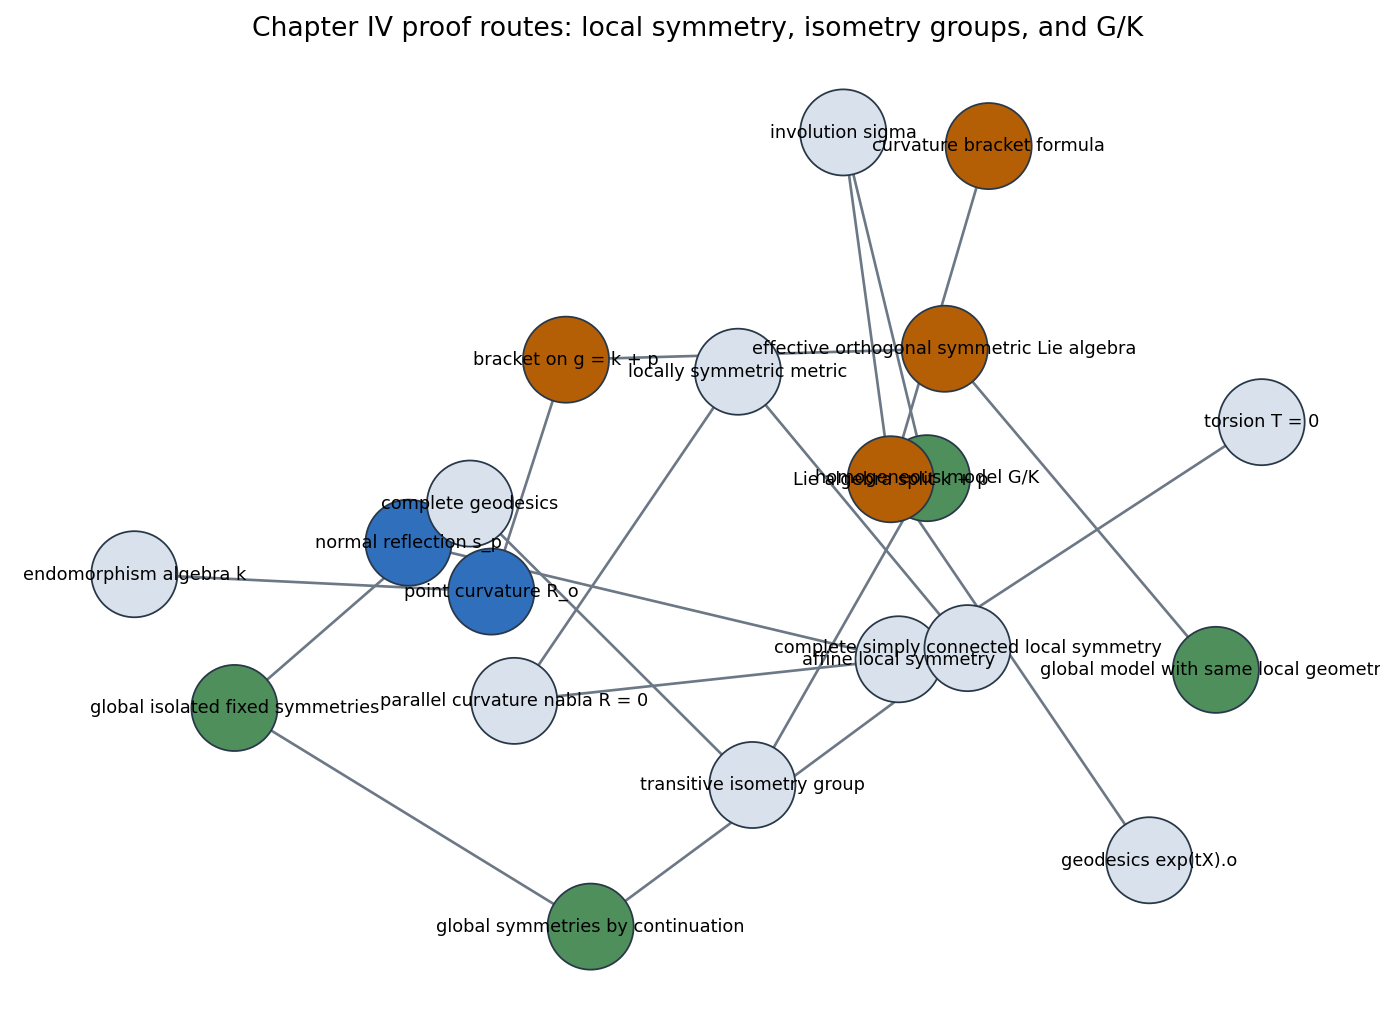

In [4]:
proof_edges = [
    ("normal reflection s_p", "affine local symmetry"),
    ("affine local symmetry", "torsion T = 0"),
    ("affine local symmetry", "parallel curvature nabla R = 0"),
    ("parallel curvature nabla R = 0", "locally symmetric metric"),
    ("locally symmetric metric", "complete simply connected local symmetry"),
    ("global isolated fixed symmetries", "complete geodesics"),
    ("complete geodesics", "transitive isometry group"),
    ("transitive isometry group", "homogeneous model G/K"),
    ("homogeneous model G/K", "involution sigma"),
    ("involution sigma", "Lie algebra split k + p"),
    ("Lie algebra split k + p", "geodesics exp(tX).o"),
    ("Lie algebra split k + p", "curvature bracket formula"),
    ("point curvature R_o", "endomorphism algebra k"),
    ("point curvature R_o", "bracket on g = k + p"),
    ("bracket on g = k + p", "effective orthogonal symmetric Lie algebra"),
    ("effective orthogonal symmetric Lie algebra", "global model with same local geometry"),
    ("complete simply connected local symmetry", "global symmetries by continuation"),
    ("global symmetries by continuation", "global isolated fixed symmetries"),
]
G = nx.DiGraph()
G.add_edges_from(proof_edges)
pos = nx.spring_layout(G, seed=7, k=0.85)

fig, ax = plt.subplots(figsize=(11, 7.8))
node_colors = []
for node in G.nodes:
    if node in {"normal reflection s_p", "point curvature R_o"}:
        node_colors.append("#2f6fbb")
    elif "G/K" in node or "global" in node:
        node_colors.append("#4f8f5b")
    elif "Lie algebra" in node or "bracket" in node:
        node_colors.append("#b45f06")
    else:
        node_colors.append("#d9e2ec")
nx.draw_networkx_edges(G, pos, ax=ax, arrowstyle="-|>", arrowsize=12, width=1.2, edge_color="#6d7886")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=1500, edgecolors="#283849", linewidths=0.8)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_title("Chapter IV proof routes: local symmetry, isometry groups, and G/K")
ax.axis("off")
proof_graph_fig = record(save_matplotlib(fig, FIGURES / "local_global_symmetric_space_dependency_graph.png"))
plt.close(fig)

proof_graph_checks = {
    "node_count": G.number_of_nodes(),
    "edge_count": G.number_of_edges(),
    "local_to_homogeneous_path_exists": nx.has_path(G, "normal reflection s_p", "homogeneous model G/K"),
    "curvature_to_global_path_exists": nx.has_path(G, "point curvature R_o", "global model with same local geometry"),
    "split_to_curvature_formula_path_exists": nx.has_path(G, "Lie algebra split k + p", "curvature bracket formula"),
}
proof_graph_report = record(save_json(proof_graph_checks, CHECKS / "local_global_dependency_graph_checks.json"))
chapter_checks["proof_graph_local_to_homogeneous"] = proof_graph_checks["local_to_homogeneous_path_exists"]
chapter_checks["proof_graph_curvature_to_global"] = proof_graph_checks["curvature_to_global_path_exists"]
print(json.dumps({"figure": rel(proof_graph_fig), "checks": rel(proof_graph_report)}, indent=2))
display_artifact(proof_graph_fig)


## 3. A Concrete Globally Symmetric Space: `S^2 = SO(3)/SO(2)`

For a base point `o` on the sphere, rotations around the vertical axis form the isotropy algebra `k`, and the two rotations that move `o` form `p`. The involution fixes `k` and negates `p`. This is the algebraic skeleton behind the formula `G/K`, and the geodesics through `o` are orbits `exp(tX).o` for `X in p`.


{
  "figure": "artifacts/chapter-04-symmetric-spaces/figures/sphere_symmetric_pair_geodesic.png",
  "table": "artifacts/chapter-04-symmetric-spaces/tables/so3_so2_symmetric_pair_brackets.csv",
  "checks": "artifacts/chapter-04-symmetric-spaces/checks/so3_so2_symmetric_pair_checks.json"
}


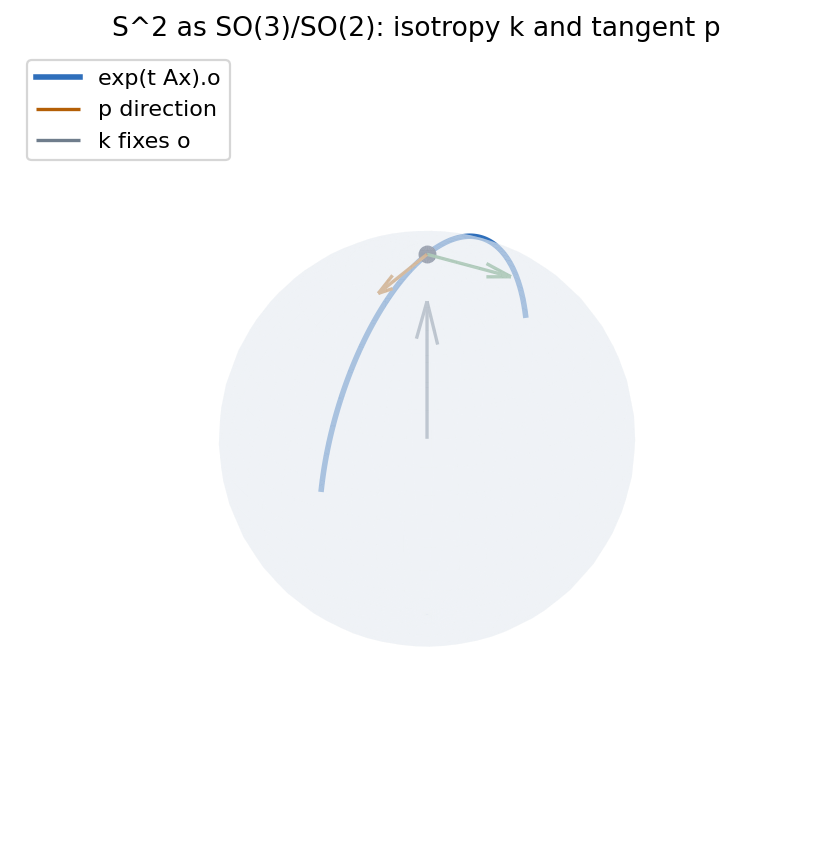

In [5]:
Ax_np = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, -1.0], [0.0, 1.0, 0.0]])
Ay_np = np.array([[0.0, 0.0, 1.0], [0.0, 0.0, 0.0], [-1.0, 0.0, 0.0]])
Az_np = np.array([[0.0, -1.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, 0.0]])
o = np.array([0.0, 0.0, 1.0])
t_values = np.linspace(-1.35, 1.35, 120)
geodesic = np.array([so3_exp(Ax_np, float(t)) @ o for t in t_values])

Ax = sp.Matrix(Ax_np.astype(int))
Ay = sp.Matrix(Ay_np.astype(int))
Az = sp.Matrix(Az_np.astype(int))
bracket_rows = [
    {"bracket": "[k,k]", "sample": "[Az,Az]", "result_space": "k", "expected": "0", "holds": bool(comm(Az, Az) == sp.zeros(3))},
    {"bracket": "[k,p]", "sample": "[Az,Ax]", "result_space": "p", "expected": "Ay", "holds": bool(comm(Az, Ax) == Ay)},
    {"bracket": "[p,p]", "sample": "[Ax,Ay]", "result_space": "k", "expected": "Az", "holds": bool(comm(Ax, Ay) == Az)},
]
sphere_pair_table = record(save_csv(bracket_rows, TABLES / "so3_so2_symmetric_pair_brackets.csv"))

u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 25)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))
fig = plt.figure(figsize=(8, 6.5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(xs, ys, zs, color="#e8edf3", alpha=0.42, linewidth=0, shade=False)
ax.plot(geodesic[:, 0], geodesic[:, 1], geodesic[:, 2], color="#2f6fbb", linewidth=2.5, label="exp(t Ax).o")
ax.scatter([o[0]], [o[1]], [o[2]], color="#1f2a44", s=50)
ax.quiver(o[0], o[1], o[2], *(Ax_np @ o), color="#b45f06", length=0.45, normalize=True, label="p direction")
ax.quiver(o[0], o[1], o[2], *(Ay_np @ o), color="#4f8f5b", length=0.45, normalize=True)
ax.quiver(0, 0, 0, 0, 0, 0.75, color="#6f7d8c", linewidth=1.5, label="k fixes o")
ax.set_title("S^2 as SO(3)/SO(2): isotropy k and tangent p")
ax.set_box_aspect((1, 1, 1))
ax.set_axis_off()
ax.legend(loc="upper left")
sphere_pair_fig = record(save_matplotlib(fig, FIGURES / "sphere_symmetric_pair_geodesic.png"))
plt.close(fig)

sphere_pair_checks = {
    "k_k_subset_k": bracket_rows[0]["holds"],
    "k_p_subset_p": bracket_rows[1]["holds"],
    "p_p_subset_k": bracket_rows[2]["holds"],
    "geodesic_points_stay_on_sphere": bool(np.max(np.abs(np.linalg.norm(geodesic, axis=1) - 1.0)) < 1e-12),
}
sphere_pair_report = record(save_json(sphere_pair_checks, CHECKS / "so3_so2_symmetric_pair_checks.json"))
chapter_checks["so3_so2_bracket_containment"] = all(sphere_pair_checks[key] for key in ["k_k_subset_k", "k_p_subset_p", "p_p_subset_k"])
chapter_checks["so3_geodesic_stays_on_sphere"] = sphere_pair_checks["geodesic_points_stay_on_sphere"]
print(json.dumps({"figure": rel(sphere_pair_fig), "table": rel(sphere_pair_table), "checks": rel(sphere_pair_report)}, indent=2))
display_artifact(sphere_pair_fig)


## 4. The Exponential Differential as a Distortion Meter

Theorem 4.1 writes `d Exp_X` in terms of powers of `(ad X)^2` on `p`. In rank one, that series collapses to familiar Jacobi factors. Compact curvature bends transverse vectors by `sin(r)/r`; noncompact curvature stretches them by `sinh(r)/r`; the flat case stays at `1`. This is the same formula viewed through three signs.


{
  "figure": "artifacts/chapter-04-symmetric-spaces/figures/exp_differential_jacobi_factors.png",
  "table": "artifacts/chapter-04-symmetric-spaces/tables/exp_differential_rank_one_factors.csv",
  "checks": "artifacts/chapter-04-symmetric-spaces/checks/exp_differential_jacobi_factor_checks.json"
}


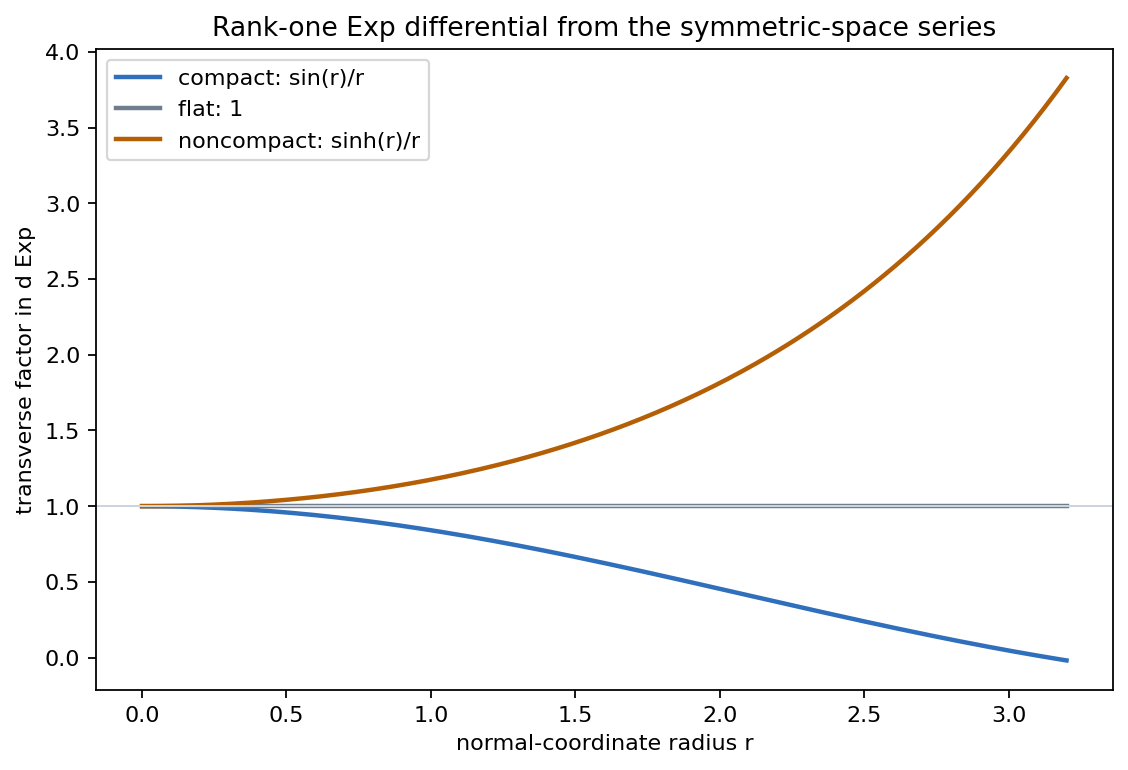

In [6]:
r = np.linspace(0.001, 3.2, 260)
sphere_factor = np.sin(r) / r
flat_factor = np.ones_like(r)
hyperbolic_factor = np.sinh(r) / r

factor_rows = []
for sample_r in [0.25, 0.75, 1.5, 2.5]:
    factor_rows.append({
        "radius": sample_r,
        "compact_sin_r_over_r": round(float(np.sin(sample_r) / sample_r), 6),
        "flat": 1.0,
        "noncompact_sinh_r_over_r": round(float(np.sinh(sample_r) / sample_r), 6),
    })
exp_factor_table = record(save_csv(factor_rows, TABLES / "exp_differential_rank_one_factors.csv"))

fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.plot(r, sphere_factor, label="compact: sin(r)/r", color="#2f6fbb", linewidth=2)
ax.plot(r, flat_factor, label="flat: 1", color="#6f7d8c", linewidth=2)
ax.plot(r, hyperbolic_factor, label="noncompact: sinh(r)/r", color="#b45f06", linewidth=2)
ax.axhline(1, color="#ccd4dd", linewidth=0.9)
ax.set_xlabel("normal-coordinate radius r")
ax.set_ylabel("transverse factor in d Exp")
ax.set_title("Rank-one Exp differential from the symmetric-space series")
ax.legend()
exp_factor_fig = record(save_matplotlib(fig, FIGURES / "exp_differential_jacobi_factors.png"))
plt.close(fig)

rr = sp.symbols("r")
series_checks = {
    "sin_r_over_r_limit": str(sp.limit(sp.sin(rr) / rr, rr, 0)),
    "sinh_r_over_r_limit": str(sp.limit(sp.sinh(rr) / rr, rr, 0)),
    "compact_below_flat_at_1": bool(np.sin(1.0) / 1.0 < 1.0),
    "noncompact_above_flat_at_1": bool(np.sinh(1.0) / 1.0 > 1.0),
    "series_sin": str(sp.series(sp.sin(rr) / rr, rr, 0, 6)),
    "series_sinh": str(sp.series(sp.sinh(rr) / rr, rr, 0, 6)),
}
exp_factor_report = record(save_json(series_checks, CHECKS / "exp_differential_jacobi_factor_checks.json"))
chapter_checks["exp_factors_have_correct_limits"] = series_checks["sin_r_over_r_limit"] == "1" and series_checks["sinh_r_over_r_limit"] == "1"
chapter_checks["exp_factors_reflect_curvature_sign"] = series_checks["compact_below_flat_at_1"] and series_checks["noncompact_above_flat_at_1"]
print(json.dumps({"figure": rel(exp_factor_fig), "table": rel(exp_factor_table), "checks": rel(exp_factor_report)}, indent=2))
display_artifact(exp_factor_fig)


## 5. Curvature from the Bracket Formula

The chapter's curvature formula is compact enough to compute exactly. In the sphere model `so(3)/so(2)`, the bracket sign gives positive sectional curvature. In the hyperbolic-plane model `sl(2,R)/so(2)`, the same formula gives negative sectional curvature with respect to the natural positive form on `p`. The point is not the normalization; it is that curvature has become a Lie bracket measurement.


{
  "figure": "artifacts/chapter-04-symmetric-spaces/figures/curvature_bracket_signs.png",
  "table": "artifacts/chapter-04-symmetric-spaces/tables/curvature_bracket_signs.csv",
  "checks": "artifacts/chapter-04-symmetric-spaces/checks/curvature_bracket_formula_checks.json"
}


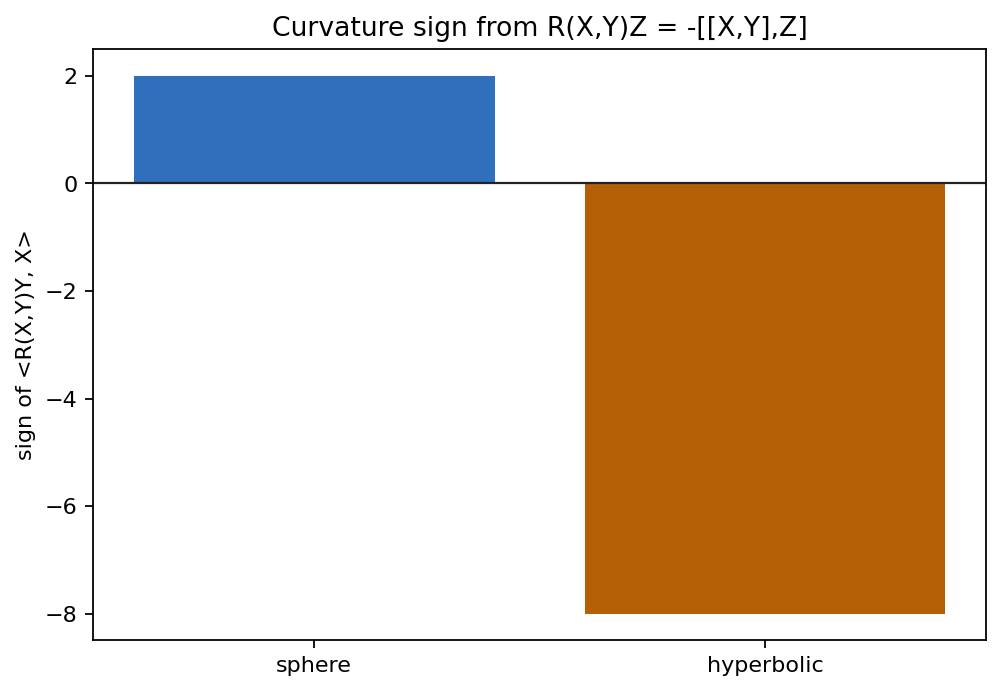

In [7]:
K = sp.Matrix([[0, 1], [-1, 0]])
P1 = sp.Matrix([[1, 0], [0, -1]])
P2 = sp.Matrix([[0, 1], [1, 0]])

def frob(A: sp.Matrix, B: sp.Matrix) -> sp.Expr:
    return sp.trace(A.T * B)

sphere_R_AxAy_Ay = -comm(comm(Ax, Ay), Ay)
sphere_sign = sp.simplify(frob(sphere_R_AxAy_Ay, Ax))
hyperbolic_R_P1P2_P2 = -comm(comm(P1, P2), P2)
hyperbolic_sign = sp.simplify(sp.trace(hyperbolic_R_P1P2_P2 * P1))

curvature_rows = [
    {
        "model": "sphere S^2 = SO(3)/SO(2)",
        "sample_formula": "-[[Ax,Ay],Ay]",
        "result_multiple": str(sphere_R_AxAy_Ay),
        "sectional_numerator_sign": str(sphere_sign),
        "interpretation": "positive",
    },
    {
        "model": "hyperbolic plane = SL(2,R)/SO(2)",
        "sample_formula": "-[[P1,P2],P2]",
        "result_multiple": str(hyperbolic_R_P1P2_P2),
        "sectional_numerator_sign": str(hyperbolic_sign),
        "interpretation": "negative",
    },
]
curvature_table = record(save_csv(curvature_rows, TABLES / "curvature_bracket_signs.csv"))

fig, ax = plt.subplots(figsize=(7.2, 4.8))
labels = ["sphere", "hyperbolic"]
values = [float(sphere_sign), float(hyperbolic_sign)]
ax.bar(labels, values, color=["#2f6fbb", "#b45f06"])
ax.axhline(0, color="#222222", linewidth=1)
ax.set_ylabel("sign of <R(X,Y)Y, X>")
ax.set_title("Curvature sign from R(X,Y)Z = -[[X,Y],Z]")
curvature_fig = record(save_matplotlib(fig, FIGURES / "curvature_bracket_signs.png"))
plt.close(fig)

curvature_checks = {
    "sphere_curvature_positive": bool(sphere_sign > 0),
    "hyperbolic_curvature_negative": bool(hyperbolic_sign < 0),
    "sphere_result_is_Ax": bool(sphere_R_AxAy_Ay == Ax),
    "hyperbolic_result_is_negative_multiple_P1": bool(hyperbolic_R_P1P2_P2 == -4 * P1),
}
curvature_report = record(save_json(curvature_checks, CHECKS / "curvature_bracket_formula_checks.json"))
chapter_checks["curvature_bracket_signs_correct"] = curvature_checks["sphere_curvature_positive"] and curvature_checks["hyperbolic_curvature_negative"]
print(json.dumps({"figure": rel(curvature_fig), "table": rel(curvature_table), "checks": rel(curvature_report)}, indent=2))
display_artifact(curvature_fig)


## 6. Reconstructing a Global Model from Local Curvature

Section 5 explains why a locally symmetric metric is not an isolated local trick. At a point, take the tangent space `p`, let `k` be the endomorphisms preserving the metric and curvature, and define brackets using the curvature tensor. The result is an orthogonal symmetric Lie algebra. The finite model below checks the Jacobi identity for constant-curvature signs `K = -1, 0, 1`, which stand for hyperbolic, flat, and spherical local geometries.


{
  "figure": "artifacts/chapter-04-symmetric-spaces/figures/local_to_global_lie_algebra_construction.png",
  "table": "artifacts/chapter-04-symmetric-spaces/tables/local_to_global_constant_curvature_brackets.csv",
  "checks": "artifacts/chapter-04-symmetric-spaces/checks/local_to_global_lie_algebra_checks.json"
}


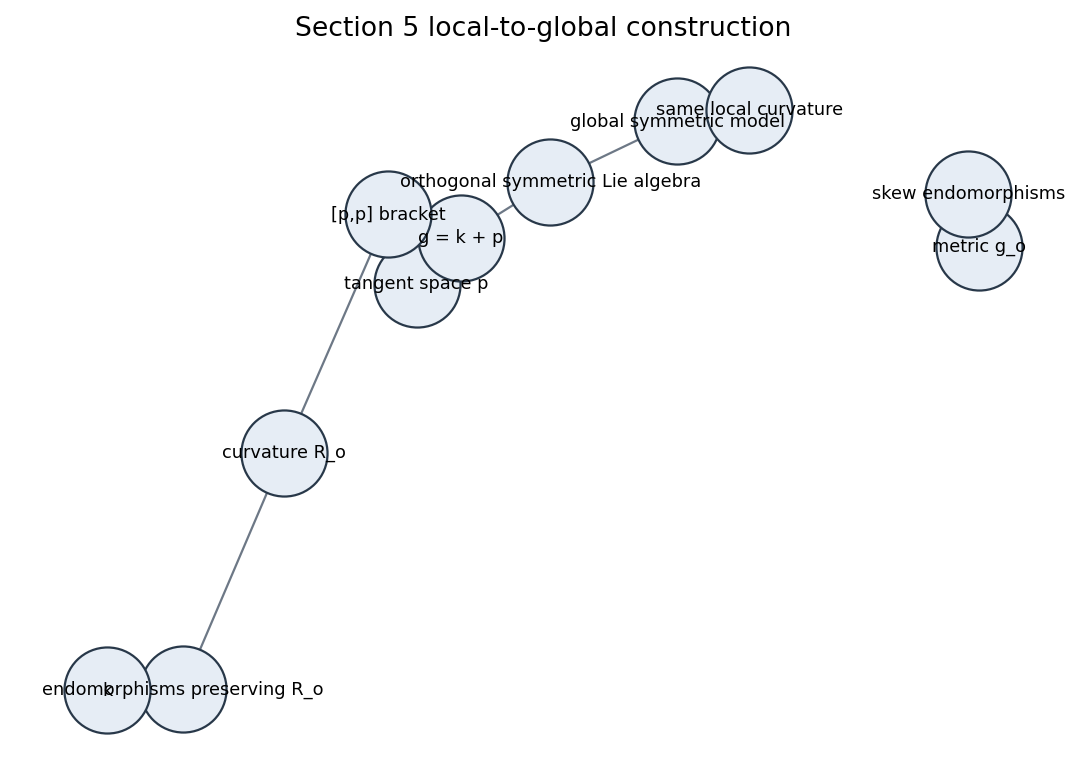

In [8]:
def bracket_const_curv(u, v, kappa):
    # Coordinates are (K0, P1, P2).  [P1,P2]=kappa*K0,
    # [K0,P1]=P2, and [K0,P2]=-P1.
    a0, a1, a2 = u
    b0, b1, b2 = v
    return np.array([
        kappa * (a1 * b2 - a2 * b1),
        -a0 * b2 + a2 * b0,
        a0 * b1 - a1 * b0,
    ], dtype=float)

basis = [
    np.array([1.0, 0.0, 0.0]),
    np.array([0.0, 1.0, 0.0]),
    np.array([0.0, 0.0, 1.0]),
]
names = ["K0", "P1", "P2"]
jacobi_rows = []
for kappa in [-1, 0, 1]:
    max_resid = 0.0
    for i, u0 in enumerate(basis):
        for j, v0 in enumerate(basis):
            for k, w0 in enumerate(basis):
                jac = (
                    bracket_const_curv(u0, bracket_const_curv(v0, w0, kappa), kappa)
                    + bracket_const_curv(v0, bracket_const_curv(w0, u0, kappa), kappa)
                    + bracket_const_curv(w0, bracket_const_curv(u0, v0, kappa), kappa)
                )
                max_resid = max(max_resid, float(np.linalg.norm(jac)))
    jacobi_rows.append({
        "curvature_K": kappa,
        "geometry": {-1: "noncompact rank-one", 0: "flat Euclidean", 1: "compact rank-one"}[kappa],
        "max_jacobi_residual": max_resid,
        "bracket_P1_P2": f"{kappa} K0",
    })
local_global_table = record(save_csv(jacobi_rows, TABLES / "local_to_global_constant_curvature_brackets.csv"))

LG = nx.DiGraph()
LG.add_edges_from([
    ("metric g_o", "skew endomorphisms"),
    ("curvature R_o", "endomorphisms preserving R_o"),
    ("endomorphisms preserving R_o", "k"),
    ("tangent space p", "g = k + p"),
    ("curvature R_o", "[p,p] bracket"),
    ("[p,p] bracket", "g = k + p"),
    ("g = k + p", "orthogonal symmetric Lie algebra"),
    ("orthogonal symmetric Lie algebra", "global symmetric model"),
    ("global symmetric model", "same local curvature"),
])
pos = nx.spring_layout(LG, seed=4)
fig, ax = plt.subplots(figsize=(8.5, 5.7))
nx.draw_networkx_edges(LG, pos, ax=ax, arrowstyle="-|>", arrowsize=12, edge_color="#6d7886")
nx.draw_networkx_nodes(LG, pos, ax=ax, node_color="#e6edf5", edgecolors="#283849", node_size=1500)
nx.draw_networkx_labels(LG, pos, ax=ax, font_size=8)
ax.set_title("Section 5 local-to-global construction")
ax.axis("off")
local_global_fig = record(save_matplotlib(fig, FIGURES / "local_to_global_lie_algebra_construction.png"))
plt.close(fig)

local_global_checks = {
    "jacobi_holds_for_K_minus_1_0_1": all(row["max_jacobi_residual"] < 1e-12 for row in jacobi_rows),
    "construction_path_exists": nx.has_path(LG, "curvature R_o", "global symmetric model"),
    "same_curvature_path_exists": nx.has_path(LG, "curvature R_o", "same local curvature"),
}
local_global_report = record(save_json(local_global_checks, CHECKS / "local_to_global_lie_algebra_checks.json"))
chapter_checks["local_to_global_jacobi_models"] = local_global_checks["jacobi_holds_for_K_minus_1_0_1"]
chapter_checks["local_to_global_graph_connected_to_model"] = local_global_checks["same_curvature_path_exists"]
print(json.dumps({"figure": rel(local_global_fig), "table": rel(local_global_table), "checks": rel(local_global_report)}, indent=2))
display_artifact(local_global_fig)


## 7. Compact Lie Groups as Symmetric Spaces

A compact connected Lie group with a bi-invariant metric becomes a globally symmetric space. Helgason presents this as `(G x G)/G*`, where the diagonal subgroup is fixed by the swap involution. On the visible group `S^1`, the symmetry at the identity is inversion `g -> g^{-1}`, and the geodesics are one-parameter subgroups.


{
  "figure": "artifacts/chapter-04-symmetric-spaces/figures/compact_lie_group_inversion_symmetry.png",
  "table": "artifacts/chapter-04-symmetric-spaces/tables/compact_lie_group_symmetric_space_formulas.csv",
  "checks": "artifacts/chapter-04-symmetric-spaces/checks/compact_lie_group_symmetry_checks.json"
}


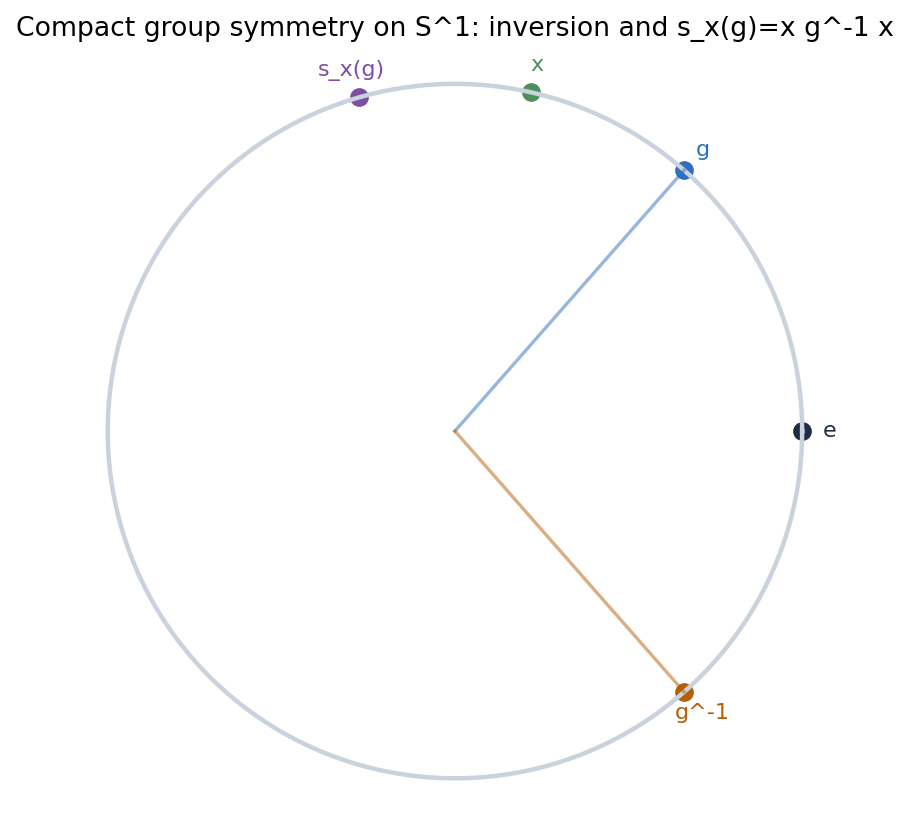

In [9]:
angles = np.linspace(0, 2 * np.pi, 320)
theta0 = 0.85
base_angle = 1.35
g_angle = theta0
inv_angle = -theta0
sx_angle = 2 * base_angle - theta0

fig, ax = plt.subplots(figsize=(6.4, 6.2))
ax.plot(np.cos(angles), np.sin(angles), color="#c9d2dd", linewidth=2)
for angle, label, color in [
    (0.0, "e", "#1f2a44"),
    (g_angle, "g", "#2f6fbb"),
    (inv_angle, "g^-1", "#b45f06"),
    (base_angle, "x", "#4f8f5b"),
    (sx_angle, "s_x(g)", "#7d4ea3"),
]:
    ax.scatter([np.cos(angle)], [np.sin(angle)], color=color, s=55)
    ax.text(1.08 * np.cos(angle), 1.08 * np.sin(angle), label, color=color, ha="center", va="center")
ax.plot([0, np.cos(g_angle)], [0, np.sin(g_angle)], color="#2f6fbb", alpha=0.5)
ax.plot([0, np.cos(inv_angle)], [0, np.sin(inv_angle)], color="#b45f06", alpha=0.5)
ax.set_aspect("equal")
ax.set_title("Compact group symmetry on S^1: inversion and s_x(g)=x g^-1 x")
ax.axis("off")
compact_group_fig = record(save_matplotlib(fig, FIGURES / "compact_lie_group_inversion_symmetry.png"))
plt.close(fig)

compact_rows = [
    {"general_object": "symmetric pair", "formula": "(G x G, diagonal G*)", "S1_witness": "S1 x S1 / diagonal"},
    {"general_object": "identity symmetry", "formula": "s_e(g)=g^-1", "S1_witness": "angle theta -> -theta"},
    {"general_object": "point symmetry", "formula": "s_x(g)=x g^-1 x", "S1_witness": "angle theta -> 2a-theta"},
    {"general_object": "geodesic", "formula": "Exp(tX)=exp(tX)", "S1_witness": "angle tX modulo 2pi"},
]
compact_group_table = record(save_csv(compact_rows, TABLES / "compact_lie_group_symmetric_space_formulas.csv"))
compact_group_checks = {
    "identity_inversion_is_involutive": bool(abs(((-(-theta0)) - theta0)) < 1e-12),
    "point_symmetry_is_involutive": bool(abs((2 * base_angle - (2 * base_angle - theta0)) - theta0) < 1e-12),
    "one_parameter_subgroup_adds_angles": bool(abs((0.4 + 0.7) - 1.1) < 1e-12),
}
compact_group_report = record(save_json(compact_group_checks, CHECKS / "compact_lie_group_symmetry_checks.json"))
chapter_checks["compact_group_symmetries_involutive"] = compact_group_checks["identity_inversion_is_involutive"] and compact_group_checks["point_symmetry_is_involutive"]
print(json.dumps({"figure": rel(compact_group_fig), "table": rel(compact_group_table), "checks": rel(compact_group_report)}, indent=2))
display_artifact(compact_group_fig)


## 8. Lie Triple Systems and Totally Geodesic Pieces

The final section identifies the tangent spaces of totally geodesic submanifolds: they are Lie triple systems inside `p`. On the sphere, a one-dimensional subspace of the tangent plane exponentiates to a great circle. The triple bracket closure test is small, but it is exactly the algebraic signal that the corresponding geometric subset does not bend away from itself.


{
  "figure": "artifacts/chapter-04-symmetric-spaces/figures/lie_triple_system_great_circles.png",
  "table": "artifacts/chapter-04-symmetric-spaces/tables/lie_triple_system_line_checks.csv",
  "checks": "artifacts/chapter-04-symmetric-spaces/checks/lie_triple_system_checks.json"
}


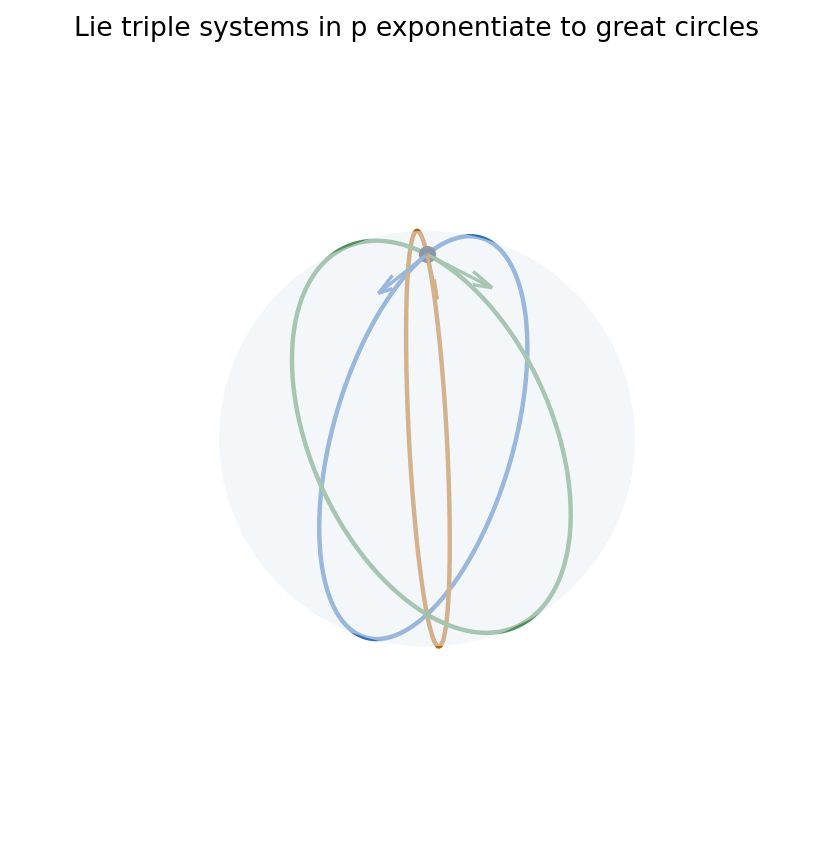

In [10]:
alphas = [0.0, math.pi / 5, 2 * math.pi / 5]
t_vals = np.linspace(-math.pi, math.pi, 240)

fig = plt.figure(figsize=(8, 6.5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(xs, ys, zs, color="#edf2f7", alpha=0.34, linewidth=0, shade=False)
colors = ["#2f6fbb", "#b45f06", "#4f8f5b"]
triple_rows = []

for alpha, color in zip(alphas, colors):
    Aline = math.cos(alpha) * Ax_np + math.sin(alpha) * Ay_np
    curve = np.array([so3_exp(Aline, float(t)) @ o for t in t_vals])
    ax.plot(curve[:, 0], curve[:, 1], curve[:, 2], color=color, linewidth=2)
    v_at_o = Aline @ o
    ax.quiver(o[0], o[1], o[2], *v_at_o, color=color, length=0.45, normalize=True)
    # A one-dimensional subspace is automatically closed under [X,[Y,Z]];
    # we still record the matrix residual for [V,[V,V]].
    V = sp.Matrix(Aline)
    triple = comm(V, comm(V, V))
    triple_rows.append({
        "alpha_radians": round(alpha, 6),
        "subspace": "span(cos(alpha) Ax + sin(alpha) Ay)",
        "triple_bracket_residual_norm": float(sum(abs(value) for value in triple)),
        "geodesic_radius_max_error": float(np.max(np.abs(np.linalg.norm(curve, axis=1) - 1.0))),
    })

ax.scatter([o[0]], [o[1]], [o[2]], color="#1f2a44", s=45)
ax.set_title("Lie triple systems in p exponentiate to great circles")
ax.set_box_aspect((1, 1, 1))
ax.set_axis_off()
triple_fig = record(save_matplotlib(fig, FIGURES / "lie_triple_system_great_circles.png"))
plt.close(fig)

triple_table = record(save_csv(triple_rows, TABLES / "lie_triple_system_line_checks.csv"))
triple_checks = {
    "sample_lines_closed_under_triple_bracket": all(row["triple_bracket_residual_norm"] < 1e-12 for row in triple_rows),
    "exponentials_stay_on_sphere": all(row["geodesic_radius_max_error"] < 1e-12 for row in triple_rows),
    "whole_p_is_lie_triple_system_in_sphere_model": bool(comm(Ax, comm(Ay, Ax)) in (Ay, -Ay, 2 * Ay, -2 * Ay)),
}
triple_report = record(save_json(triple_checks, CHECKS / "lie_triple_system_checks.json"))
chapter_checks["lie_triple_sample_lines_close"] = triple_checks["sample_lines_closed_under_triple_bracket"]
chapter_checks["lie_triple_exponentials_stay_on_sphere"] = triple_checks["exponentials_stay_on_sphere"]
print(json.dumps({"figure": rel(triple_fig), "table": rel(triple_table), "checks": rel(triple_report)}, indent=2))
display_artifact(triple_fig)


## Applied Lab: Change the Curvature Sign

Use the constant-curvature bracket model from Section 6 as the lab surface. Change `K` among `-1`, `0`, and `1`, then inspect three consequences:

1. the bracket `[P1,P2] = K K0`,
2. the transverse Exp factor (`sinh(r)/r`, `1`, or `sin(r)/r`),
3. the sign of the curvature numerator.

The chapter's main point is that these are not separate facts. In a symmetric space they are three windows into the same `k+p` algebra.


In [11]:
lab_rows = []
for kappa in [-1, 0, 1]:
    if kappa < 0:
        factor = "sinh(r)/r"
        sign = "negative"
    elif kappa == 0:
        factor = "1"
        sign = "zero"
    else:
        factor = "sin(r)/r"
        sign = "positive"
    bracket_p1p2 = bracket_const_curv(basis[1], basis[2], kappa)
    lab_rows.append({
        "K": kappa,
        "bracket_vector_[P1,P2]_(K0,P1,P2)": tuple(float(x) for x in bracket_p1p2),
        "Exp_transverse_factor": factor,
        "curvature_sign": sign,
    })
lab_table = record(save_csv(lab_rows, TABLES / "curvature_sign_lab.csv"))
lab_checks = {
    "three_curvature_signs_present": sorted(row["curvature_sign"] for row in lab_rows) == ["negative", "positive", "zero"],
    "flat_bracket_p1p2_zero": lab_rows[1]["bracket_vector_[P1,P2]_(K0,P1,P2)"] == (0.0, 0.0, 0.0),
}
lab_report = record(save_json(lab_checks, CHECKS / "curvature_sign_lab_checks.json"))
chapter_checks["curvature_sign_lab_consistent"] = lab_checks["three_curvature_signs_present"] and lab_checks["flat_bracket_p1p2_zero"]
print(json.dumps({"table": rel(lab_table), "checks": rel(lab_report)}, indent=2))
display_artifact(lab_table)


{
  "table": "artifacts/chapter-04-symmetric-spaces/tables/curvature_sign_lab.csv",
  "checks": "artifacts/chapter-04-symmetric-spaces/checks/curvature_sign_lab_checks.json"
}


[curvature_sign_lab.csv](artifacts/chapter-04-symmetric-spaces/tables/curvature_sign_lab.csv)

## Takeaways

- Local symmetry means more than a pretty reflection: it is the condition that torsion vanishes and curvature is parallel, so the local reflection preserves the affine/Riemannian data.
- Global symmetry turns the manifold into a homogeneous space `G/K`; the involution of `G` gives the tangent decomposition `g = k + p`.
- The formulas for geodesics, the exponential differential, parallel translation, and curvature are bracket formulas once the `k+p` split is known.
- A locally symmetric space carries enough pointwise curvature data to build a global symmetric model with the same local geometry.
- Compact Lie groups and totally geodesic submanifolds are not side examples: they are tests that the symmetric-pair formalism is doing actual geometry.


In [12]:
final_sanity = {
    "chapter": "Chapter IV. Symmetric Spaces",
    "source_span": "printed pages 198-228, approximately PDF pages 225-255",
    "artifact_count": len(artifact_paths),
    "artifacts": [rel(path) for path in artifact_paths],
    "checks": chapter_checks,
    "coverage_note": "Sections 1-7 are represented by local symmetry diagrams, proof graphs, G/K models, Exp differential factors, exact curvature brackets, local-to-global Jacobi checks, compact group symmetry, and Lie triple systems.",
}
failed = [name for name, value in chapter_checks.items() if isinstance(value, bool) and not value]
if failed:
    raise AssertionError(f"Chapter sanity checks failed: {failed}")
final_sanity_path = record(save_json(final_sanity, CHECKS / "final_sanity.json"))
assert_artifacts(artifact_paths, min_bytes=64)
assert_artifacts([final_sanity_path], min_bytes=64)
print(json.dumps({"final_sanity": rel(final_sanity_path), "boolean_checks": len([v for v in chapter_checks.values() if isinstance(v, bool)]), "failed": failed}, indent=2))
display_artifact(final_sanity_path)


{
  "final_sanity": "artifacts/chapter-04-symmetric-spaces/checks/final_sanity.json",
  "boolean_checks": 16,
  "failed": []
}


`final_sanity.json`